## Langchain Version v1

In [4]:
import os
from dotenv import load_dotenv
from langchain.agents import create_agent

load_dotenv()

True

### Lets see how we can create agents 
#### 1. Simple agent without tools

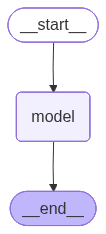

In [12]:
agent = create_agent(
    "gpt-5-mini",
    tools=[],
    system_prompt="You are a helpful assistant",
)
agent

In [9]:
agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the weather today in New York?",
                }
        ]
    }
)

{'messages': [HumanMessage(content='What is the weather today in New York?', additional_kwargs={}, response_metadata={}, id='3286d0ad-a230-422e-b829-619600a94db3'),
  AIMessage(content='I don’t have access to live internet data, so I can’t fetch the current, real-time weather for you. I can, however:\n\n- Tell you typical weather for early May in New York City (climatology),\n- Give quick ways you can get the current conditions right now, and\n- Help interpret any forecast or raw API output if you paste it here.\n\nTypical conditions for New York City on May 1\n- Average high: ~65–68°F (18–20°C)\n- Average low: ~50–54°F (10–12°C)\n- Weather: mild; showers or a passing cold front are possible at this time of year\n\nQuick ways to get the current weather right now\n- Open a browser or phone and search: “New York weather” or “weather New York, NY” (Google, Weather.com, NWS).\n- National Weather Service (best for official alerts): https://www.weather.gov and search New York, NY.\n- Quick t

#### 2. Agent with Tools

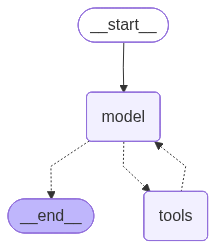

In [ ]:
def get_weather(city: str) -> str:
    """Get the current weather in a city"""
    return f"The weather in {city} today is sunny"

agent_with_tools = create_agent(
    "gpt-5-mini",
    tools=[get_weather],
    system_prompt="You are a helpful assistant",
)
agent_with_tools 

In [16]:
output = agent_with_tools.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the weather today in New York?",
                }
        ]
    }
)
output

{'messages': [HumanMessage(content='What is the weather today in New York?', additional_kwargs={}, response_metadata={}, id='07c7e649-0c4c-4a16-a92d-415a6edf27af'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 144, 'total_tokens': 232, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DaiCERTp2zh7y6LLFE1dZusmn3iZ9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019de3b9-5e47-74c0-a237-ad809b7a0246-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_CvU9rjPMwe7fJneE4Xkxwg7c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 144, 'ou

In [17]:
output["messages"][-1].content

'Today in New York it’s sunny.\n\nWould you like more details (current temperature, hourly forecast, wind, chance of rain, or the outlook for tomorrow)?'

In [19]:
output = agent_with_tools.invoke({"messages": "What is the weather today in Chicago?"})
output

{'messages': [HumanMessage(content='What is the weather today in Chicago?', additional_kwargs={}, response_metadata={}, id='282f0b6e-61cd-4cac-bfc2-4563cc5b064c'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 143, 'total_tokens': 166, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DaiFZLVpr7KwPcqC5hKmUKjHCnHrh', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019de3bc-8251-7323-921d-cbc8685a7812-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Chicago'}, 'id': 'call_1wGnVEM3I9GO0hCSbIEBuUY8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 143, 'outpu